In [1]:
import numpy as np
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

In [ ]:
def classical_detect_boxes(img: Image.Image,
                           min_width=8,
                           max_width_ratio=0.25,
                           col_smooth=9,
                           edge_thresh_quantile=0.75,
                           band_thresh_quantile=0.80):
    # grayscale
    arr = np.asarray(img.convert("L"), dtype=np.float32) / 255.0

    # horizontal gradient magnitude (abs(diff) across x)
    gx = np.abs(np.diff(arr, axis=1))
    gx = np.pad(gx, ((0, 0), (0, 1)), mode="edge")

    # reduce to a column edge-energy profile
    col_energy = gx.mean(axis=0)

    # smooth the column energy to reduce noise
    if col_smooth and col_smooth > 1:
        k = int(col_smooth)
        kernel = np.ones(k, dtype=np.float32) / k
        col_energy = np.convolve(col_energy, kernel, mode="same")

    # threshold + find contiguous “high-edge” vertical bands
    e_thr = float(np.quantile(col_energy, edge_thresh_quantile))
    mask = col_energy >= e_thr

    w = arr.shape[1]
    max_width = int(max(1, w * max_width_ratio))

    segments = []
    in_seg = False
    start = 0
    for x in range(w):
        if mask[x] and not in_seg:
            in_seg = True
            start = x
        if in_seg and (not mask[x] or x == w - 1):
            end = x if not mask[x] else x + 1
            in_seg = False
            if end - start >= min_width and end - start <= max_width:
                segments.append((start, end))

    boxes = []
    scores = []
    for x1, x2 in segments:
        band = gx[:, x1:x2]
        if band.size == 0:
            continue

        # for each band, estimate a y-range and output a box
        # y-range estimated by looking for strong edge rows within the vertical band
        row_energy = band.mean(axis=1)
        y_thr = float(np.quantile(row_energy, band_thresh_quantile))
        ys = np.where(row_energy >= y_thr)[0]
        if ys.size == 0:
            y1, y2 = 0, arr.shape[0]
        else:
            y1 = int(max(0, ys.min() - 5))
            y2 = int(min(arr.shape[0], ys.max() + 6))
            if y2 - y1 < 10:
                y1, y2 = 0, arr.shape[0]

        boxes.append([float(x1), float(y1), float(x2), float(y2)])

        # boxes + scores 
        # score = average column edge energy inside this x-band
        scores.append(float(col_energy[x1:x2].mean()))

    if len(boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)
    order = np.argsort(-scores)
    boxes = boxes[order]
    scores = scores[order]
    return boxes, scores


In [4]:
def box_iou_np(boxes1: np.ndarray, boxes2: np.ndarray) -> np.ndarray:
    if boxes1.size == 0 or boxes2.size == 0:
        return np.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=np.float32)

    b1 = boxes1.astype(np.float32)
    b2 = boxes2.astype(np.float32)

    xa = np.maximum(b1[:, None, 0], b2[None, :, 0])
    ya = np.maximum(b1[:, None, 1], b2[None, :, 1])
    xb = np.minimum(b1[:, None, 2], b2[None, :, 2])
    yb = np.minimum(b1[:, None, 3], b2[None, :, 3])

    inter = np.clip(xb - xa, a_min=0, a_max=None) * np.clip(yb - ya, a_min=0, a_max=None)
    area1 = np.clip(b1[:, 2] - b1[:, 0], 0, None) * np.clip(b1[:, 3] - b1[:, 1], 0, None)
    area2 = np.clip(b2[:, 2] - b2[:, 0], 0, None) * np.clip(b2[:, 3] - b2[:, 1], 0, None)
    union = area1[:, None] + area2[None, :] - inter

    out = np.zeros_like(inter, dtype=np.float32)
    valid = union > 0
    out[valid] = inter[valid] / union[valid]
    return out


def voc_ap(rec: np.ndarray, prec: np.ndarray) -> float:
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))

    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))
    return ap


def evaluate_ap50_classical(split_name: str,
                            score_thresh: float = 0.05,
                            iou_thresh: float = 0.5,
                            max_images: int | None = None):
    split_dir = Path(f"data/LibVision-2/{split_name}")
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    image_paths = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts])
    if max_images is not None:
        image_paths = image_paths[:max_images]

    det_scores = []
    det_tp = []
    gt_total = 0

    for img_path in image_paths:
        with Image.open(img_path) as im:
            img = im.convert("RGB")

        gt_boxes = load_gt_book_boxes(img_path, labels_dir)
        gt_total += int(gt_boxes.shape[0])

        pred_boxes, pred_scores = classical_detect_boxes(img)
        keep = pred_scores >= float(score_thresh)
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]

        if pred_boxes.shape[0] == 0:
            continue

        order = np.argsort(-pred_scores)
        pred_boxes = pred_boxes[order]
        pred_scores = pred_scores[order]

        matched = np.zeros((gt_boxes.shape[0],), dtype=bool)
        ious = box_iou_np(pred_boxes, gt_boxes)

        for j in range(pred_boxes.shape[0]):
            det_scores.append(float(pred_scores[j]))
            if gt_boxes.shape[0] == 0:
                det_tp.append(0)
                continue

            best_gt = int(np.argmax(ious[j]))
            best_iou = float(ious[j, best_gt])
            if best_iou >= iou_thresh and not matched[best_gt]:
                matched[best_gt] = True
                det_tp.append(1)
            else:
                det_tp.append(0)

    scores = np.array(det_scores, dtype=np.float32)
    tps = np.array(det_tp, dtype=np.int32)

    if scores.size == 0:
        ap = 0.0
    else:
        order = np.argsort(-scores)
        tps = tps[order]
        fps = 1 - tps

        tp_cum = np.cumsum(tps)
        fp_cum = np.cumsum(fps)

        rec = tp_cum / max(1, gt_total)
        prec = tp_cum / np.maximum(1, (tp_cum + fp_cum))
        ap = voc_ap(rec, prec)

    print(f"Classical Book AP@0.5 on {split_name} (IoU={iou_thresh}, score>={score_thresh}): {ap:.4f} (GT={gt_total}, imgs={len(image_paths)})")
    return ap


_ = evaluate_ap50_classical("valid", score_thresh=0.05, iou_thresh=0.5)


Classical Book AP@0.5 on valid (IoU=0.5, score>=0.05): 0.0007 (GT=1658, imgs=96)


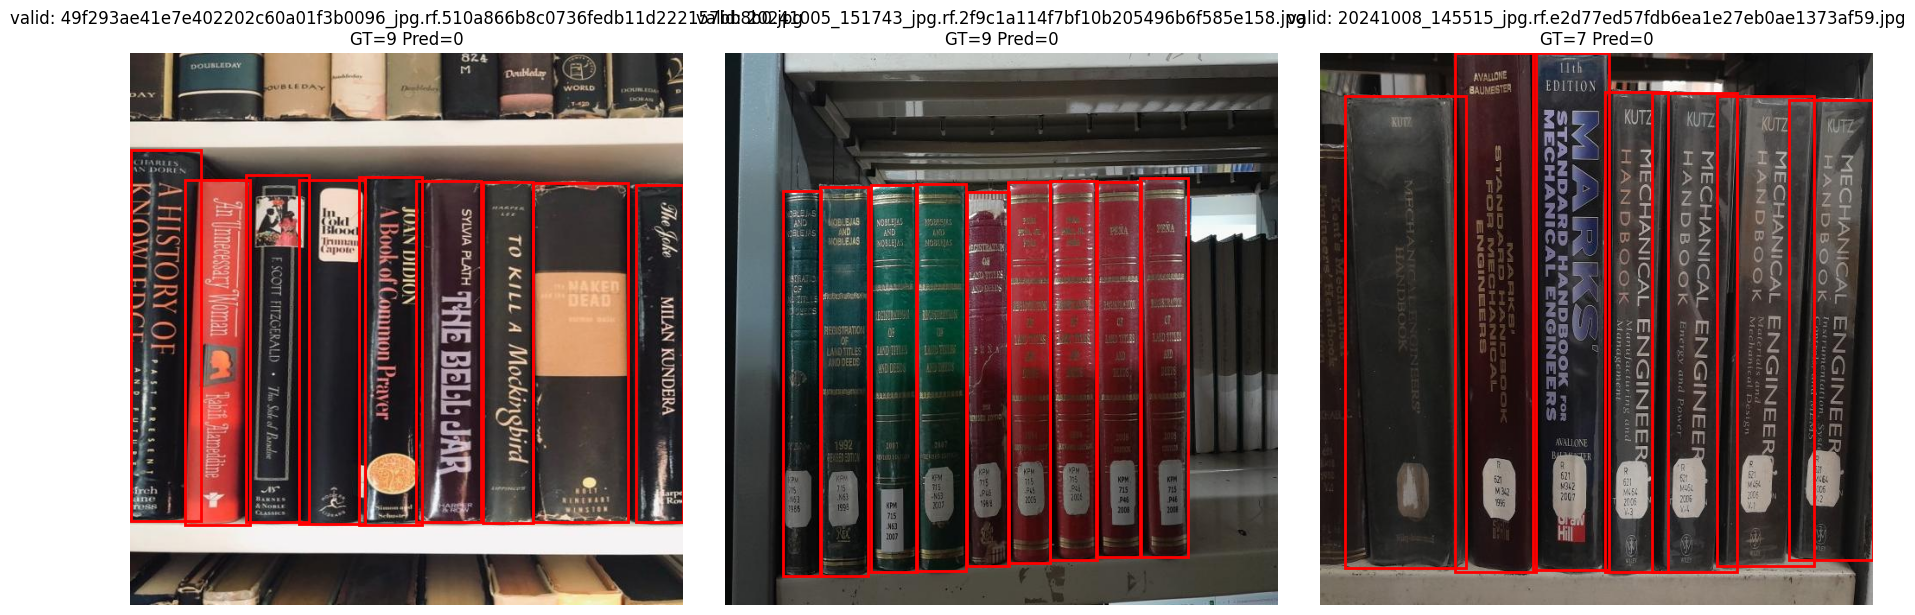

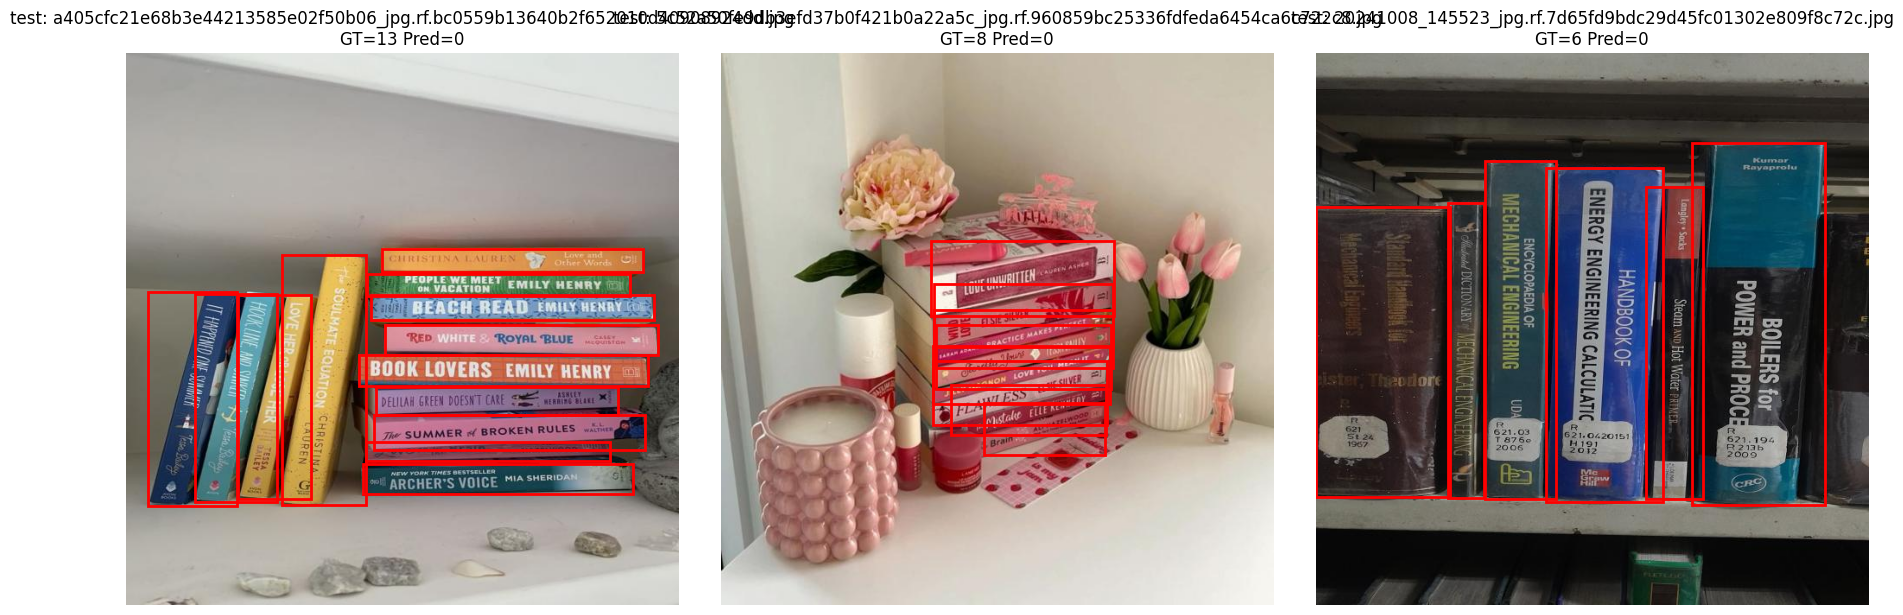

In [5]:
def visualize_classical(split_name: str, n: int = 3, score_thresh: float = 0.5, seed: int = 0):
    split_dir = Path(f"data/LibVision-2/{split_name}")
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    image_paths = sorted([p for p in images_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts])

    rng = random.Random(seed)
    rng.shuffle(image_paths)
    chosen = image_paths[:n]

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]

    for ax, img_path in zip(axes, chosen):
        with Image.open(img_path) as im:
            img = im.convert("RGB")

        gt_boxes = load_gt_book_boxes(img_path, labels_dir)
        pred_boxes, pred_scores = classical_detect_boxes(img)

        keep = pred_scores >= float(score_thresh)
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]

        ax.imshow(np.asarray(img))

        for (x1, y1, x2, y2) in gt_boxes:
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     fill=False, edgecolor="red", linewidth=2)
            ax.add_patch(rect)

        for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     fill=False, edgecolor="lime", linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, max(0, y1 - 5), f"book {float(s):.2f}", color="lime", fontsize=9,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))

        ax.set_title(f"{split_name}: {img_path.name}\nGT={len(gt_boxes)} Pred={len(pred_boxes)}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_classical("valid", n=3, score_thresh=0.5, seed=0)
visualize_classical("test", n=3, score_thresh=0.5, seed=1)
